In [ ]:
# use hyriver

Saved image: usgs_gages_map.png


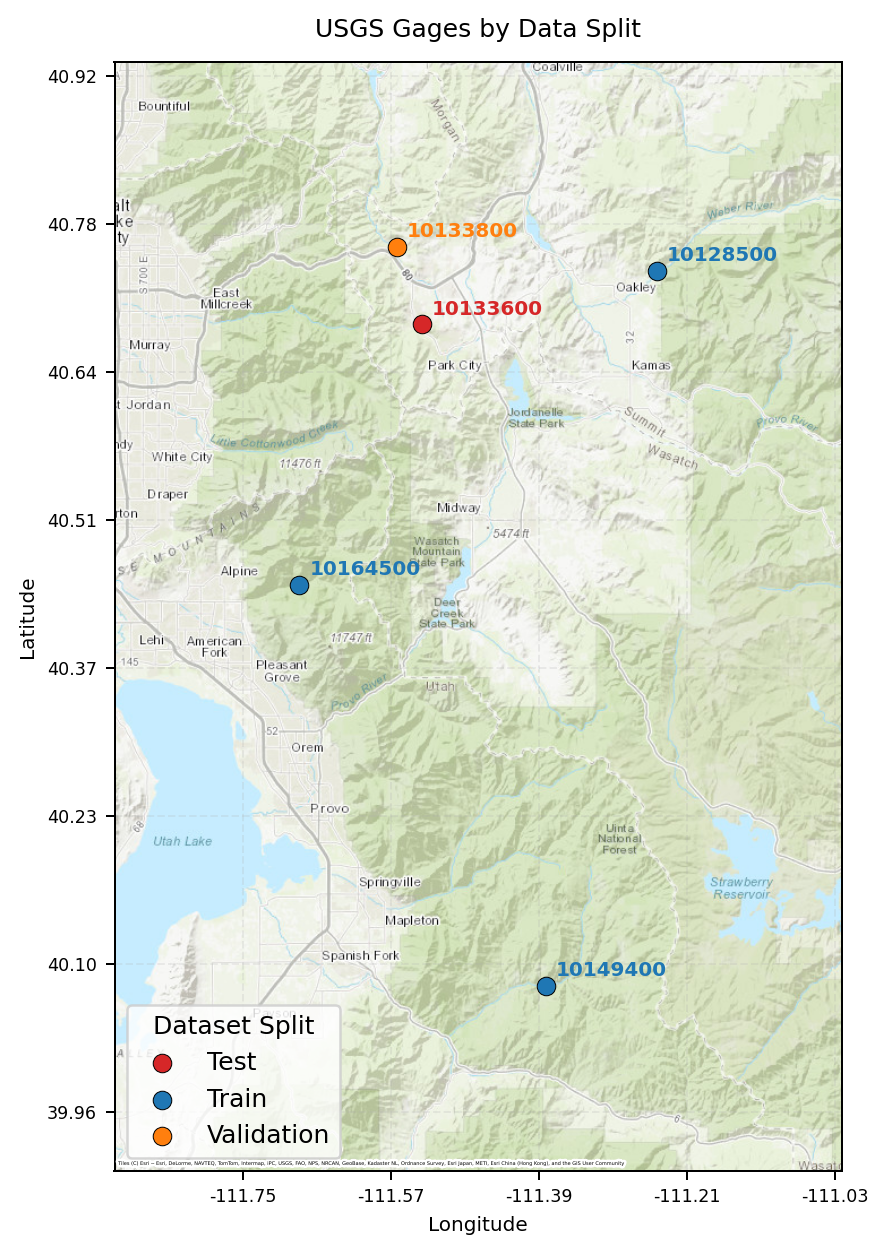

In [20]:
# GeoPandas map with topographic basemap + lon/lat axis labels + PNG export
# pip install dataretrieval geopandas matplotlib contextily xyzservices pyproj  # if needed

import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
from dataretrieval import nwis
from matplotlib.ticker import FuncFormatter
from pyproj import Transformer

# -----------------------------
# 1) Define train/val/test sites
# -----------------------------
TRAIN_SITES = ["10149400", "10128500", "10164500"]
VAL_SITE = ["10133800"]
TEST_SITE = ["10133600"]

site_groups = {
    "Train": TRAIN_SITES,
    "Validation": VAL_SITE,
    "Test": TEST_SITE,
}

group_colors = {
    "Train": "#1f77b4",       # blue
    "Validation": "#ff7f0e",  # orange
    "Test": "#d62728",        # red
}

all_sites = [s for group in site_groups.values() for s in group]

# -----------------------------
# 2) Get station metadata
# -----------------------------
info = nwis.get_info(sites=all_sites)[0]
gages = (
    info[["site_no", "station_nm", "dec_lat_va", "dec_long_va"]]
    .dropna()
    .copy()
)
gages["site_no"] = gages["site_no"].astype(str)
gages["dec_lat_va"] = pd.to_numeric(gages["dec_lat_va"])
gages["dec_long_va"] = pd.to_numeric(gages["dec_long_va"])

site_to_group = {s: g for g, sites in site_groups.items() for s in sites}
gages["group"] = gages["site_no"].map(site_to_group)

# Convert to GeoDataFrame in lon/lat, then to Web Mercator for tile basemaps
gages_gdf = gpd.GeoDataFrame(
    gages,
    geometry=gpd.points_from_xy(gages["dec_long_va"], gages["dec_lat_va"]),
    crs="EPSG:4326",
)
gages_web = gages_gdf.to_crs(epsg=3857)

# -----------------------------
# 3) Topographic basemap + points
# -----------------------------
# Build a stable extent from gage bounds (meters in EPSG:3857)
xmin, ymin, xmax, ymax = gages_web.total_bounds
width = max(xmax - xmin, 1.0)
height = max(ymax - ymin, 1.0)

# 12% padding with a minimum 25 km buffer
xpad = max(width * 0.12, 25000.0)
ypad = max(height * 0.12, 25000.0)
xlim = (xmin - xpad, xmax + xpad)
ylim = (ymin - ypad, ymax + ypad)

fig, ax = plt.subplots(figsize=(11, 8), dpi=180)

# Set extent first
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)

# Add topographic basemap
cx.add_basemap(
    ax,
    source=cx.providers.Esri.WorldTopoMap,
    crs=gages_web.crs.to_string(),
    reset_extent=False,
    attribution_size=2,
)

# Plot each split with a different color
for group_name, group_df in gages_web.groupby("group"):
    group_df.plot(
        ax=ax,
        color=group_colors[group_name],
        markersize=55,
        label=group_name,
        edgecolor="black",
        linewidth=0.4,
        zorder=4,
    )

# Permanent text labels (site numbers)
for _, row in gages_web.iterrows():
    ax.annotate(
        row["site_no"],
        xy=(row.geometry.x, row.geometry.y),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8,
        fontweight="bold",
        color=group_colors[row["group"]],
        zorder=5,
    )

# Lock extent again to prevent any autoscale drift
ax.set_xlim(*xlim)
ax.set_ylim(*ylim)
ax.set_aspect("equal")

# Show lon/lat tick labels while keeping Web Mercator plotting coordinates
to_lonlat = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)

def format_lon(x, pos):
    lon, _ = to_lonlat.transform(x, ylim[0])
    return f"{lon:.2f}"

def format_lat(y, pos):
    _, lat = to_lonlat.transform(xlim[0], y)
    return f"{lat:.2f}"

ax.xaxis.set_major_formatter(FuncFormatter(format_lon))
ax.yaxis.set_major_formatter(FuncFormatter(format_lat))

ax.set_title("USGS Gages by Data Split", fontsize=10, pad=10)
ax.set_xlabel("Longitude", fontsize=8)
ax.set_ylabel("Latitude", fontsize=8)
ax.tick_params(axis="both", labelsize=7)
ax.legend(title="Dataset Split", loc="lower left")
ax.grid(alpha=0.2, linestyle="--", zorder=1)

# -----------------------------
# 4) Save map as PNG
# -----------------------------
png_file = "usgs_gages_map.png"
fig.savefig(png_file, bbox_inches="tight")

print(f"Saved image: {png_file}")
plt.show()